# GRAPEX Micrometeorology – Advection Analysis

Explores micrometeorological data from the **GRAPEX Ripperdam** experiment to study the advection effect of fallow fields on nearby vineyards.

**Data:** `GRAPEX_Advection_2024_Micromet_Data.xlsx` — half-hourly tower measurements at four sites:
| Site | Description |
|------|-------------|
| Fallow | Bare/idle field (upwind reference) |
| R761 | Harvested vineyard |
| R771 | Upwind vineyard |
| R760 | Downwind vineyard (primary advection-affected site) |

**Analysis steps:**
1. Load and parse Excel sheets; build `units` and `variables` lookup dicts from the Key sheet  
2. Combine datetime components into a single `date` column  
3. Plot timeseries of key variables (LST, ET, NDVI, etc.) across all four sites  
4. Compute and visualise spatial transects of LST, ET, and NDVI as a function of distance from the fallow field

In [ ]:
import os
import pandas as pd
import matplotlib.pylab as plt
import numpy as np
import warnings
import rioxarray                # raster I/O (not used directly here but available)
import matplotlib.dates as mdates  # date formatting for timeseries axes

# Suppress noisy projection / dtype warnings from rasterio / pandas
warnings.filterwarnings("ignore")

In [ ]:
# Root path to the GRAPEX Ripperdam advection experiment data
root = '/Users/octaviacrompton/Google_Drive_quatratavia/projects/advection_problem/Ripperdam'

In [3]:
import pandas as pd

# Load the Excel workbook and inspect available sheet names
file_path = root + '/GRAPEX_Advection_2024_Micromet_Data.xlsx'
excel_data = pd.ExcelFile(file_path)

# Expected sheets: 'Key', 'Fallow', 'R761', 'R771', 'R760'
sheet_names = excel_data.sheet_names
sheet_names

FileNotFoundError: [Errno 2] No such file or directory: '/Users/octaviacrompton/Google_Drive_quatratavia/projects/advection_problem/Ripperdam/GRAPEX_Advection_2024_Micromet_Data.xlsx'

In [ ]:
# Parse each sheet; row index 2 (0-based) holds the column headers in this workbook
# The Key sheet maps variable codes → descriptions and units
key_df = excel_data.parse('Key', header=2)

# Skip the first data row (index 0) which contains units, not observations
fallow_df = excel_data.parse('Fallow', header=2)[1:]   # bare/idle field
r761_df   = excel_data.parse('R761',   header=2)[1:]   # harvested vineyard
r771_df   = excel_data.parse('R771',   header=2)[1:]   # upwind vineyard
r760_df   = excel_data.parse('R760',   header=2)[1:]   # downwind vineyard (advection-affected)

In [ ]:
# Build a lookup dict: column header → physical units string (e.g. 'LE' → 'W m-2')
units = {}
for i in key_df.index:
    units[key_df.loc[i]['Field Header']] = key_df.loc[i]['Units']

In [ ]:
# Build a lookup dict: column header → human-readable description (e.g. 'LE' → 'Latent Heat Flux')
variables = {}
for i in key_df.index:
    variables[key_df.loc[i]['Field Header']] = key_df.loc[i]['Description ']

In [ ]:
variables

{'Year': 'Year',
 'Month': 'Month',
 'Day': 'Day',
 'Hour': 'Hour',
 'Minute': 'Minute',
 'Second': 'Second',
 'DOY': 'Day of Year',
 'TOD': 'Time of Day',
 'DEC': 'Decimal Time',
 'WSpd': 'Wind Speed',
 'WDir': 'Wind Direction',
 'WDir std': 'Wind Direction (sd)',
 'Tsnc': 'Sonic Temperature',
 'Tair': 'Air Temperature',
 'rho_v': 'Water Vapor Density',
 'eact': 'Actual Water Vapor Pressure',
 'esat': 'Saturation Water Vapor Pressure',
 'D': 'Water Vapor Pressure Deficit',
 'rho_c': 'Carbon Dioxide Concentration',
 'P': 'Atmospheric Pressure',
 'rho_a': 'Air Density',
 'Cp': 'Specific Heat',
 'Lv': 'Latent Heat of Vaporization',
 'Kin': 'Incident Solar Radiation',
 'Kup': 'Reflected Solar Radiation',
 'Lin': 'Incident Longwave Radiation',
 'Lup': 'Terrestrial Longwave Radiaion',
 'Rn': 'Net Radiation',
 'G': 'Soil Heat Flux',
 'H': 'Sensible Heat Flux',
 'LE': 'Latent Heat Flux',
 'Fx': 'Exchange Flux',
 'Fc': 'Carbon Dioxide Flux',
 'ustar': 'Friction Velocity',
 'L': 'Obukhov Length

In [ ]:
variables['rho_v'] + " " + units['rho_v']

'Water Vapor Density [g m-3]'

In [ ]:
# Combine the separate Year / Month / Day / Hour / Minute / Second columns
# into a single datetime column for timeseries plotting
for df in [fallow_df, r761_df, r771_df, r760_df]:
    df['date'] = pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second']])

In [ ]:
def plot_timeseries(dataframes, sites, variable, ax):
    """
    Plots a timeseries for a given variable across multiple sites.
    
    Parameters:
    - dataframes (list of pd.DataFrame): List of dataframes containing data for each site.
    - sites (list of str): List of site names corresponding to each dataframe.
    - variable (str): The variable to analyze (column name in each dataframe).
    - variables (dict): A dictionary mapping variable column names to display names for the y-axis and title.
    - ax (matplotlib.axes._subplots.AxesSubplot): Matplotlib axis object for plotting.
    """
    varname = variables[variable]
    unit = units[variable]
    # Plot each site's data
    for site, df in zip(sites, dataframes):
        dates = pd.to_datetime(df['date'], errors='coerce')
        data = pd.to_numeric(df[variable], errors='coerce')
        ax.plot(dates, data, label=long_names[site],  c= colors[site], linestyle='-', marker='o', markersize=3)

    # Customize plot
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%y'))    
    ax.set_xlabel('Date')
    ax.set_title(varname)
    ax.set_ylabel(varname + " " + unit)
    ax.legend()
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()



## Plotting functions

`plot_timeseries` – line plot of a chosen variable across all sites over calendar time.  
`plot_diurnal_cycle` – mean ± 95 % CI of a variable grouped by hour of day, for each site.

In [ ]:
# Display names for each site used in legend labels
long_names = {
    'Fallow': 'Fallow',
    'R761':   'R761 (harvested)',
    'R771':   'R771 (upwind)',
    'R760':   'R760 (downwind)',
}

In [ ]:
variables['Rhasp Hi']

'Relative Humidity (High)'

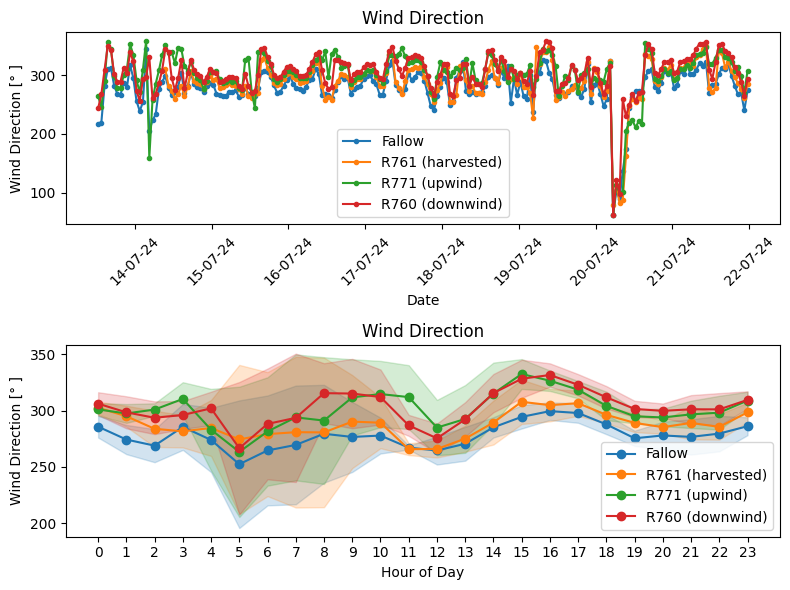

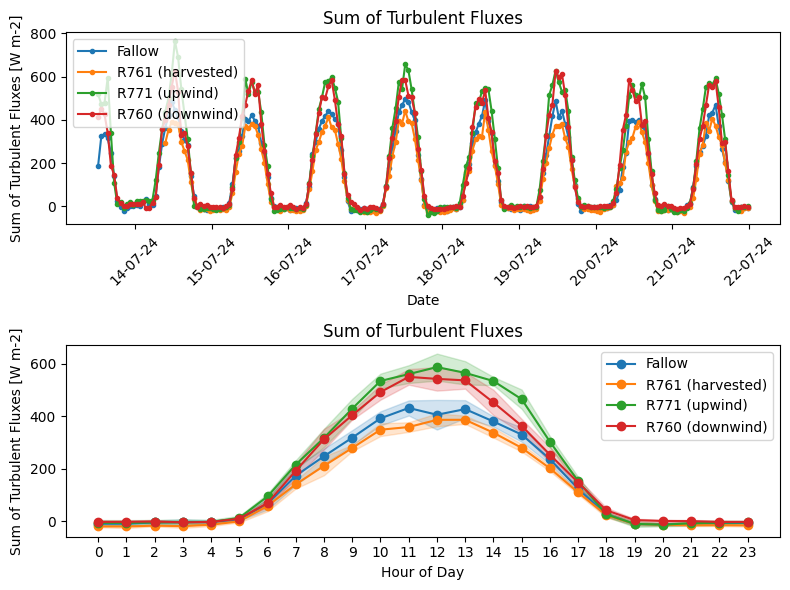

In [ ]:
import matplotlib.dates as mdates

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_diurnal_cycle(dataframes, sites, variable, ax):
    """
    Plots the diurnal cycle with confidence intervals for each site.
    
    Parameters:
    - dataframes (list of pd.DataFrame): List of dataframes containing data for each site.
    - sites (list of str): List of site names corresponding to each dataframe.
    - variable (str): The variable to analyze (column name in each dataframe).
    - varname (str): The variable name for labeling the plot (y-axis and title).
    """
    varname = variables[variable]
    unit = units[variable]    
    diurnal_stats = {}
    for site, df in zip(sites, dataframes):
        # Ensure the variable column is numeric and drop NaNs
        df[variable] = pd.to_numeric(df[variable], errors='coerce')
        df_cleaned = df.dropna(subset=[variable])

        # Calculate mean, std, and CI for each hour
        hourly_stats = df_cleaned.groupby('Hour')[variable].agg(['mean', 'std', 'count'])
        hourly_stats['ci'] = 1.96 * hourly_stats['std'] / np.sqrt(hourly_stats['count'])
        
        diurnal_stats[site] = hourly_stats

    # Plot the diurnal cycle for each site with confidence intervals
    for label, stats in diurnal_stats.items():

        ax.plot(stats.index, stats['mean'], label=long_names[label], marker='o', c = colors[label])
        ax.fill_between(stats.index, stats['mean'] - stats['ci'], stats['mean'] + stats['ci'], alpha=0.2,
                        color = colors[label])
    
    # Customize plot
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel(varname + " " + unit)
    ax.set_title(varname)
    ax.legend()
    ax.set_xticks(range(0, 24, 1))
    plt.tight_layout()



variable = 'Tmasp Lo'
variable = 'LE'
variable = 'rho_v'
# variable = 'Tair'
# variable = 'Fx'
# variable = 'WSpd'
# variable = 'ustar'
variable = 'WDir'


colors = {'Fallow'  : 'C0', 'R761' :'C1', 'R771' : 'C2', 'R760' :'C3'} 

dataframes = [fallow_df, r761_df, r771_df, r760_df]
sites = ['Fallow', 'R761', 'R771', 'R760']

# dataframes=[fallow_df, r771_df, r760_df]
# sites=['Fallow',  'R771', 'R760']

fig, axes = plt.subplots(2,1, figsize = (8, 6))

plot_timeseries(
    dataframes=dataframes,
    sites=sites,
    variable=variable,
    ax=axes[0]
)   

plot_diurnal_cycle(
    dataframes=dataframes,
    sites=sites,
    variable=variable,
    ax = axes[1]
)

variable = 'T'
colors = {'Fallow'  : 'C0', 'R761' :'C1', 'R771' : 'C2', 'R760' :'C3'} 

dataframes = [fallow_df, r761_df, r771_df, r760_df]
sites = ['Fallow', 'R761', 'R771', 'R760']

# dataframes=[fallow_df, r771_df, r760_df]
# sites=['Fallow',  'R771', 'R760']

fig, axes = plt.subplots(2,1, figsize = (8, 6))

plot_timeseries(
    dataframes=dataframes,
    sites=sites,
    variable=variable,
    ax=axes[0]
)   

plot_diurnal_cycle(
    dataframes=dataframes,
    sites=sites,
    variable=variable,
    ax = axes[1]
)



## Timeseries and diurnal cycle – selected variable

Plots a two-panel figure: (top) timeseries; (bottom) diurnal cycle.  
Set `variable` to any key in `variables` (e.g. `'LE'`, `'H'`, `'Tsfc'`, `'WDir'`).

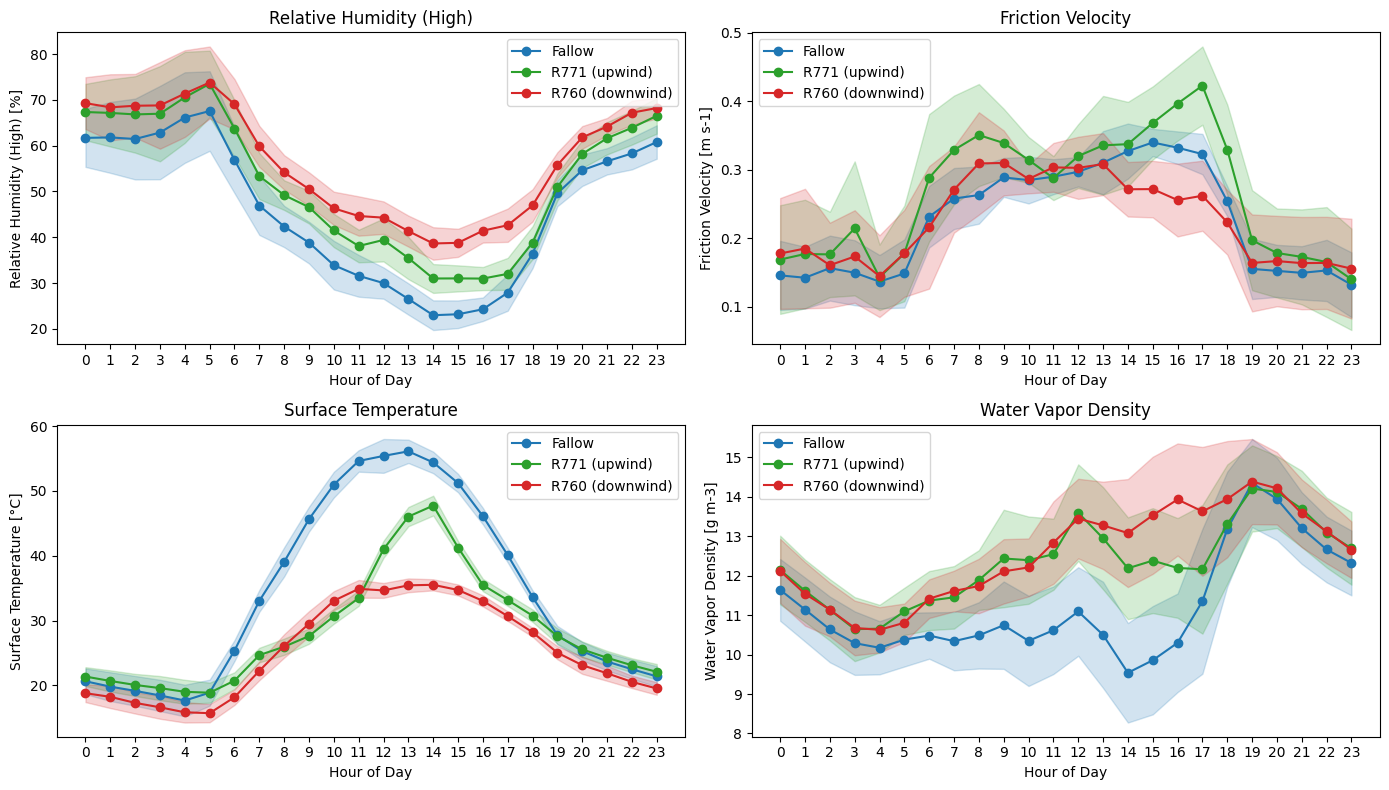

In [ ]:
# variable = 'T'

colors = {'Fallow'  : 'C0', 'R761' :'C1', 'R771' : 'C2', 'R760' :'C3'} 

dataframes = [fallow_df, r761_df, r771_df, r760_df]
sites = ['Fallow', 'R761', 'R771', 'R760']

dataframes=[fallow_df, r771_df, r760_df]
sites=['Fallow',  'R771', 'R760']

fig, axes = plt.subplots(2,2, figsize = (14, 8))

axes = axes.ravel()
variable = 'Rhasp Hi'
plot_diurnal_cycle(
    dataframes=dataframes,
    sites=sites,
    variable=variable,
    ax = axes[0]
)

variable = 'ustar'
plot_diurnal_cycle(
    dataframes=dataframes,
    sites=sites,
    variable=variable,
    ax = axes[1]
)

variable = 'Tsfc'
plot_diurnal_cycle(
    dataframes=dataframes,
    sites=sites,
    variable=variable,
    ax = axes[2]
)


variable = 'rho_v'
plot_diurnal_cycle(
    dataframes=dataframes,
    sites=sites,
    variable=variable,
    ax = axes[3]
)



## Multi-variable diurnal comparison (southwesterly winds only)

Filter observations to `WDir > 200°` to isolate advection-relevant conditions (SW fetch over the fallow field toward R760).  
Four-panel diurnal: LE, H, Tsfc, ρᵥ — Fallow vs. R760 only.

In [ ]:
# hourly_stats = r761_df.groupby('Hour')["LE"].agg(['mean', 'std', 'count'])
# plt.plot(hourly_stats['mean'])


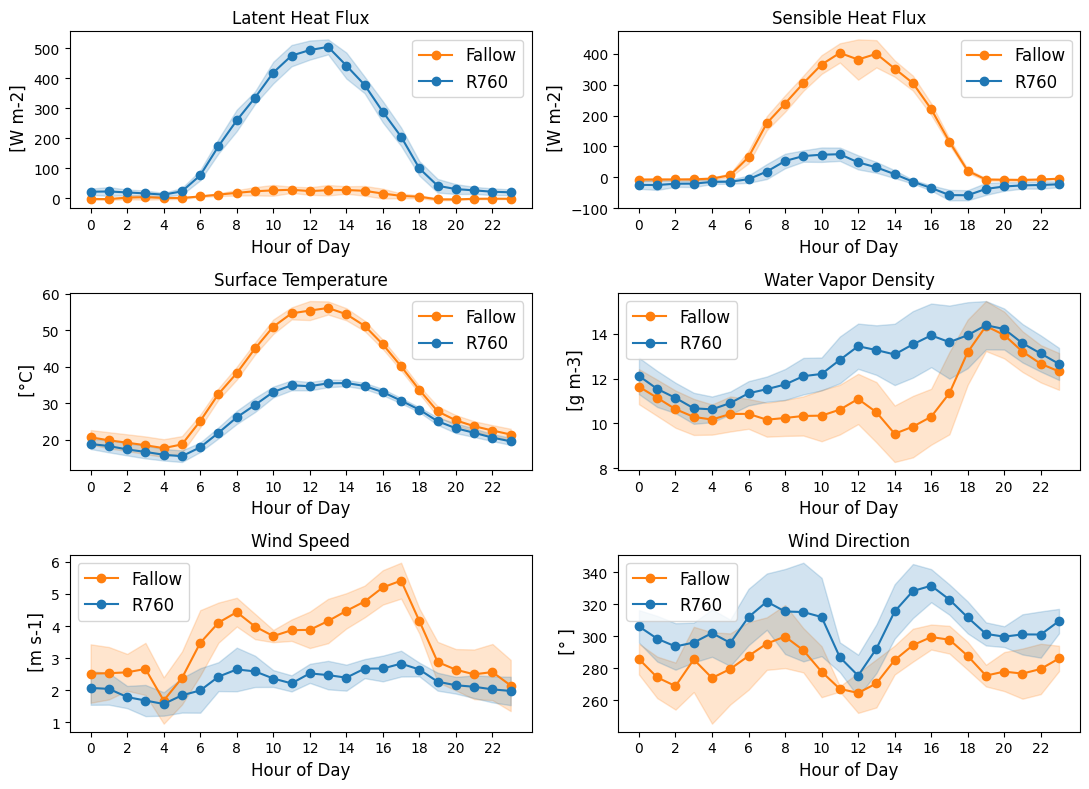

In [ ]:

def plot_diurnal_cycle(dataframes, sites, variable, ax):
    """
    Plots the diurnal cycle with confidence intervals for each site.
    
    Parameters:
    - dataframes (list of pd.DataFrame): List of dataframes containing data for each site.
    - sites (list of str): List of site names corresponding to each dataframe.
    - variable (str): The variable to analyze (column name in each dataframe).
    - varname (str): The variable name for labeling the plot (y-axis and title).
    """
    varname = variables[variable]
    unit = units[variable]    
    diurnal_stats = {}
    for site, df in zip(sites, dataframes):
        # Ensure the variable column is numeric and drop NaNs
        df[variable] = pd.to_numeric(df[variable], errors='coerce')
        df_cleaned = df.dropna(subset=[variable]).query("WDir > 200")

        # Calculate mean, std, and CI for each hour
        hourly_stats = df_cleaned.groupby('Hour')[variable].agg(['mean', 'std', 'count'])
        hourly_stats['ci'] = 1.96 * hourly_stats['std'] / np.sqrt(hourly_stats['count'])
        
        diurnal_stats[site] = hourly_stats

    # Plot the diurnal cycle for each site with confidence intervals
    for label, stats in diurnal_stats.items():

        ax.plot(stats.index, stats['mean'], label=label, marker='o', c = colors[label])
        ax.fill_between(stats.index, stats['mean'] - stats['ci'], stats['mean'] + stats['ci'], alpha=0.2,
                        color = colors[label])
    
    # Customize plot
    ax.set_xlabel('Hour of Day', fontsize = 12)
    ax.set_ylabel( " " + unit, fontsize = 12)
    ax.set_title(varname, fontsize = 12)
    ax.legend(fontsize = 12)
    ax.set_xticks(range(0, 24, 2))
    plt.tight_layout()
    
dataframes=[fallow_df, r760_df]
sites=['Fallow',  'R760']

colors = {'Fallow'  : 'C1', 'R761' :'C1', 'R771' : 'C0', 'R760' :'C0'} 


fig, axes = plt.subplots(3,2, figsize = (11, 8))

axes = axes.ravel()
variable = 'LE'
plot_diurnal_cycle(
    dataframes=dataframes,
    sites=sites,
    variable=variable,
    ax = axes[0]
)

variable = 'H'
plot_diurnal_cycle(
    dataframes=dataframes,
    sites=sites,
    variable=variable,
    ax = axes[1]
)

variable = 'Tsfc'
plot_diurnal_cycle(
    dataframes=dataframes,
    sites=sites,
    variable=variable,
    ax = axes[2]
)


variable = 'rho_v'
plot_diurnal_cycle(
    dataframes=dataframes,
    sites=sites,
    variable=variable,
    ax = axes[3]
)


variable = 'WSpd'
plot_diurnal_cycle(
    dataframes=dataframes,
    sites=sites,
    variable=variable,
    ax = axes[4]
)


variable = 'WDir'
plot_diurnal_cycle(
    dataframes=dataframes,
    sites=sites,
    variable=variable,
    ax = axes[5]
)



In [ ]:
# variables

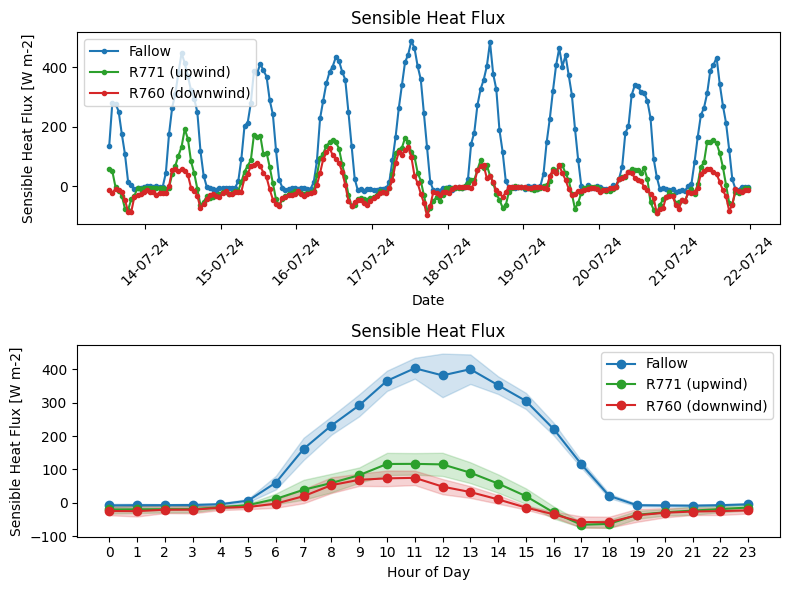

In [ ]:
variable = 'H'

colors = {'Fallow'  : 'C0', 'R761' :'C1', 'R771' : 'C2', 'R760' :'C3'} 

dataframes = [fallow_df, r761_df, r771_df, r760_df]
sites = ['Fallow', 'R761', 'R771', 'R760']


dataframes=[fallow_df, r771_df, r760_df]
sites=['Fallow',  'R771', 'R760']

fig, axes = plt.subplots(2,1, figsize = (8, 6))
plot_timeseries(
    dataframes=dataframes,
    sites=sites,
    variable=variable,
    ax=axes[0]
)   

plot_diurnal_cycle(
    dataframes=dataframes,
    sites=sites,
    variable=variable,
    ax = axes[1]
)



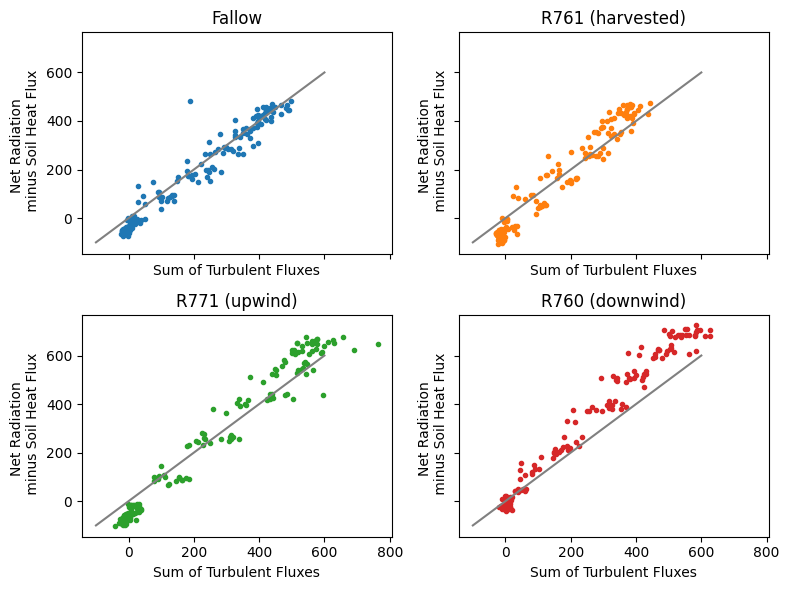

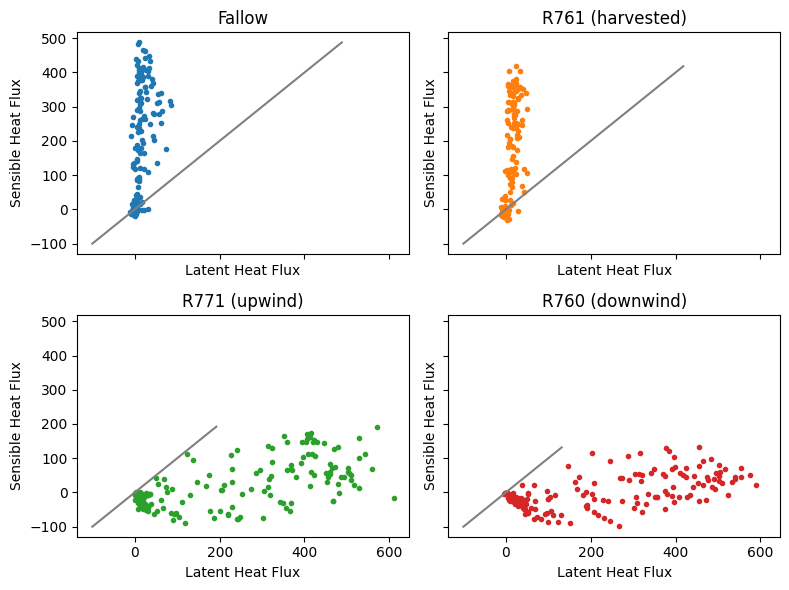

In [ ]:

dataframes = [fallow_df, r761_df, r771_df, r760_df]
sites = ['Fallow', 'R761', 'R771', 'R760']

fig, axes = plt.subplots(2, 2, figsize = (8, 6), sharex = True, sharey = True)
axes = axes.ravel()

i = 0
for site, df in zip(sites, dataframes):
    ax = axes[i]
    ax.plot(df['T'], df['Rn'] - df['G'], '.', c = colors[site],  label = site)
    i+=1
    ax.plot([-100, 600], [-100, 600], 'grey')
    ax.set_title(long_names[site])
    ax.set_xlabel(variables['T'])
    ax.set_ylabel(variables['Rn']+ " \n minus " + variables['G'])
plt.tight_layout()
        



fig, axes = plt.subplots(2, 2, figsize = (8, 6), sharex = True, sharey = True)
axes = axes.ravel()

i = 0
for site, df in zip(sites, dataframes):
    ax = axes[i]
    ax.plot(df['LE'], df['H'], '.', c = colors[site],  label = site)
    i+=1
    ax.plot([-100, np.nanmax(df['H'])], [-100, np.nanmax(df['H'])], 'grey')
    ax.set_title(long_names[site])
    ax.set_xlabel(variables['LE'])
    ax.set_ylabel(variables['H'])
plt.tight_layout()
        


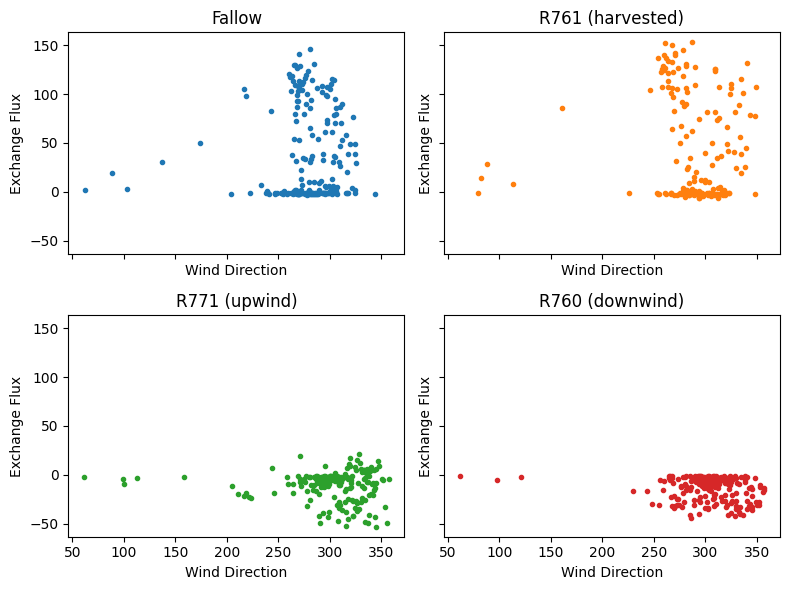

In [ ]:
fig, axes = plt.subplots(2, 2, figsize = (8, 6), sharex = True, sharey = True)
axes = axes.ravel()

i = 0
for site, df in zip(sites, dataframes):
    ax = axes[i]
    ax.plot(df['WDir'], df['Fx'], '.', c = colors[site],  label = site)
    i+=1

    ax.set_title(long_names[site])
    ax.set_xlabel(variables['WDir'])
    ax.set_ylabel(variables['Fx'])
plt.tight_layout()
        
# plt.scatter(fallow_df['WDir'], fallow_df['Fx'])


Tsfc
Tcan
Tsoil


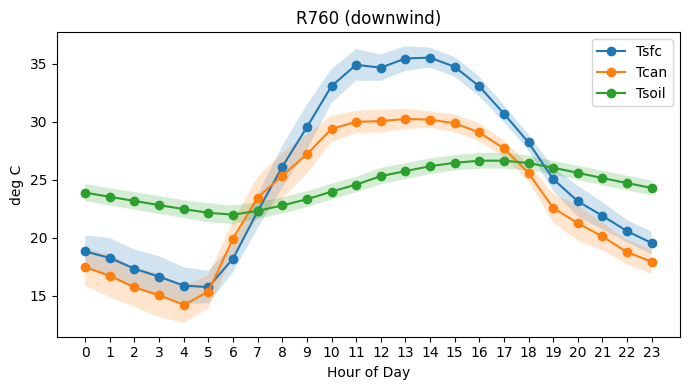

In [ ]:
# ['Key', 'Fallow', 'R761', 'R771', 'R760']

tmp = fallow_df; sitename = 'fallow'
tmp = r771_df; sitename = '771'
tmp = r760_df; sitename = long_names['R760']
# tmp = r761_df; sitename = '761'

diurnal_stats = {}
for variable, df in zip(['Tsfc', 'Tcan', 'Tsoil'], [tmp, tmp, tmp]):
    # Filter to include only numeric values in variable and drop NaNs
    df[variable] = pd.to_numeric(df[variable], errors='coerce')
    df_cleaned = df.dropna(subset=[variable])
    
    # Calculate the mean, std, and CI for each hour
    hourly_stats = df_cleaned.groupby('Hour')[variable].agg(['mean', 'std', 'count'])
    hourly_stats['mean'] = pd.to_numeric(hourly_stats['mean'], errors='coerce')
    hourly_stats['std'] = pd.to_numeric(hourly_stats['std'], errors='coerce')
    hourly_stats['count'] = pd.to_numeric(hourly_stats['count'], errors='coerce')
    
    # Calculate confidence interval
    hourly_stats['ci'] = 1.96 * hourly_stats['std'] / np.sqrt(hourly_stats['count'])
    print (variable)
    diurnal_stats[variable] = hourly_stats

# Plot the diurnal cycle of friction velocity with confidence intervals
plt.figure(figsize=(7, 4))

# Plot each site's diurnal cycle with CIs
for label, stats in diurnal_stats.items():
    plt.plot(stats.index, stats['mean'], label=label, marker='o')
    plt.fill_between(stats.index, stats['mean'] - stats['ci'], stats['mean'] + stats['ci'], alpha=0.2)

# Add plot details
plt.xlabel('Hour of Day')
plt.ylabel('deg C')
plt.title(sitename)
plt.legend()

plt.xticks(range(0, 24, 1))
plt.tight_layout()
plt.show()


In [ ]:
variables

{'Year': 'Year',
 'Month': 'Month',
 'Day': 'Day',
 'Hour': 'Hour',
 'Minute': 'Minute',
 'Second': 'Second',
 'DOY': 'Day of Year',
 'TOD': 'Time of Day',
 'DEC': 'Decimal Time',
 'WSpd': 'Wind Speed',
 'WDir': 'Wind Direction',
 'WDir std': 'Wind Direction (sd)',
 'Tsnc': 'Sonic Temperature',
 'Tair': 'Air Temperature',
 'rho_v': 'Water Vapor Density',
 'eact': 'Actual Water Vapor Pressure',
 'esat': 'Saturation Water Vapor Pressure',
 'D': 'Water Vapor Pressure Deficit',
 'rho_c': 'Carbon Dioxide Concentration',
 'P': 'Atmospheric Pressure',
 'rho_a': 'Air Density',
 'Cp': 'Specific Heat',
 'Lv': 'Latent Heat of Vaporization',
 'Kin': 'Incident Solar Radiation',
 'Kup': 'Reflected Solar Radiation',
 'Lin': 'Incident Longwave Radiation',
 'Lup': 'Terrestrial Longwave Radiaion',
 'Rn': 'Net Radiation',
 'G': 'Soil Heat Flux',
 'H': 'Sensible Heat Flux',
 'LE': 'Latent Heat Flux',
 'Fx': 'Exchange Flux',
 'Fc': 'Carbon Dioxide Flux',
 'ustar': 'Friction Velocity',
 'L': 'Obukhov Length

In [ ]:
x_var_list = ['WSpd', 'WDir', 'WDir std', 'Tsnc', 'Tair', 'rho_v', 'eact', 'esat', 'D', 'rho_c', 'P', 'rho_a', 'Kin', 'Kup', 'Lin', 'Lup', 'Rn', 'G', 'H', 'LE', 'Fx', 'Fc', 'ustar', 'L',
    'z/L', 'Albedo', 'A ', 'T', 'R', 'C ', 'Tsfc', 'Tcan', 'Tsoil', 'VWC']




dict_keys(['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second', 'DOY', 'TOD', 'DEC', 'WSpd', 'WDir', 'WDir std', 'Tsnc', 'Tair', 'rho_v', 'eact', 'esat', 'D', 'rho_c', 'P', 'rho_a', 'Cp', 'Lv', 'Kin', 'Kup', 'Lin', 'Lup', 'Rn', 'G', 'H', 'LE', 'Fx', 'Fc', 'ustar', 'L', 'z/L', 'Albedo', 'A ', 'T', 'R', 'C ', 'Tsfc', 'Tcan', 'Tsoil', 'VWC', 'Tasp Hi', 'Tasp Lo', 'Rhasp Hi', 'Rhasp Lo', 'Battery'])

Text(0.5, 1.0, 'Indep variables = WDir, WSpd')

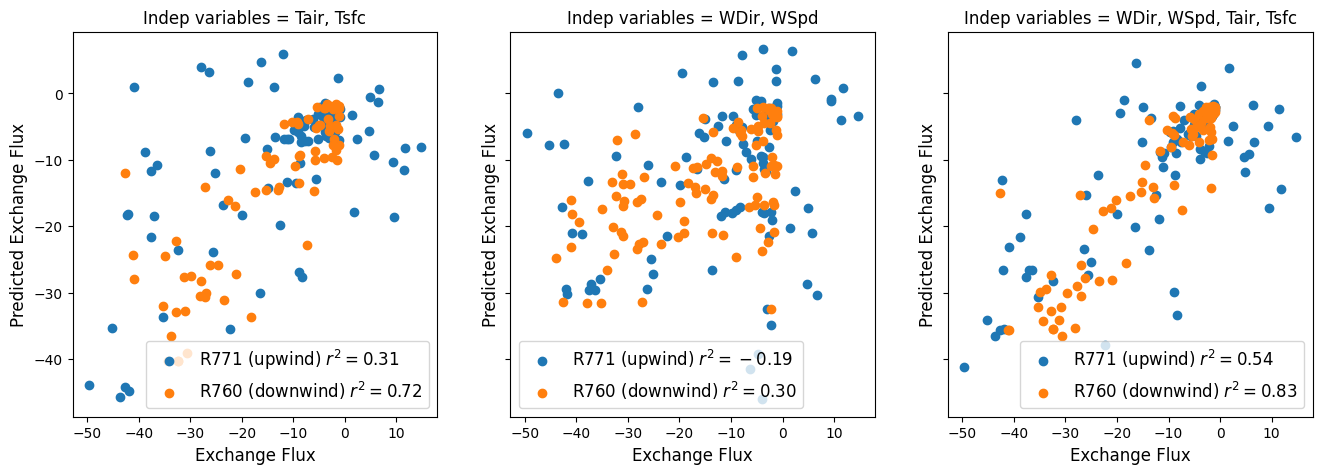

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

def predict_fx(dataframe, y_var , x_vars):
    """
    Predicts Fx from Wdir and WSpd using a Random Forest Regressor.

    """
    # Check for necessary columns

    dataframe = dataframe[x_vars + [ y_var]].dropna()
    # Define features (X) and target (y)
    X = dataframe[x_vars]
    y = dataframe[y_var]

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

    # Initialize and train the model
    model = RandomForestRegressor(random_state=42, n_estimators=100)
    model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = model.predict(X_test)

    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)


    return {
        'mse': mse,
        'r2': r2,
        'y_pred' : y_pred,
        'y_test' : y_test

    }


dataframes = [fallow_df, r761_df, r771_df, r760_df]
sites = ['Fallow', 'R761', 'R771', 'R760']

dataframes = [ r771_df, r760_df]
sites = ['R771', 'R760']


y_var = 'Fx'

fig, axes = plt.subplots(1, 3, figsize= (16,5), sharex = True, sharey = True)
axes = axes.ravel()

x_vars = [ 'Tair', 'Tsfc']
ax = axes[0]
for site, df in zip(sites, dataframes):

    results = predict_fx(df, y_var, x_vars)

    ax.scatter(results['y_test'],results['y_pred'], 
               label = long_names[site] + f" $r^2={results['r2']:.2f}$")
    ax.legend(fontsize = 12)
    
ax.set_xlabel(f"{variables[y_var]}", fontsize = 12)
ax.set_ylabel(f"Predicted {variables[y_var]}",fontsize = 12)
ax.set_title('Indep variables = ' + ', '.join(x_vars), fontsize = 12)


x_vars = ['WDir', 'WSpd',  'Tair', 'Tsfc']

ax = axes[2]
for site, df in zip(sites, dataframes):
    #print ("site", long_names[site])
    results = predict_fx(df, y_var, x_vars)
    #print(f"Mean Squared Error: {results['mse']:.2f}")
    #print(f"R² Score: {results['r2']:.2f}")

    ax.scatter(results['y_test'],results['y_pred'],  label = long_names[site] + f" $r^2={results['r2']:.2f}$")
    ax.legend(fontsize = 12)
    
ax.set_xlabel(f"{variables[y_var]}",fontsize = 12)
ax.set_ylabel(f"Predicted {variables[y_var]}", fontsize = 12)
ax.set_title('Indep variables = ' + ', '.join(x_vars), fontsize = 12)


x_vars = ['WDir', 'WSpd', ]
ax = axes[1]
for site, df in zip(sites, dataframes):

    results = predict_fx(df, y_var, x_vars)

    ax.scatter(results['y_test'],results['y_pred'], 
               label = long_names[site] + f" $r^2={results['r2']:.2f}$")
    ax.legend(fontsize = 12)
    
ax.set_xlabel(f"{variables[y_var]}", fontsize = 12)
ax.set_ylabel(f"Predicted {variables[y_var]}",fontsize = 12)
ax.set_title('Indep variables = ' + ', '.join(x_vars), fontsize = 12)




Text(0.5, 1.0, 'Indep variables = WDir, WSpd, Tair, Tsfc')

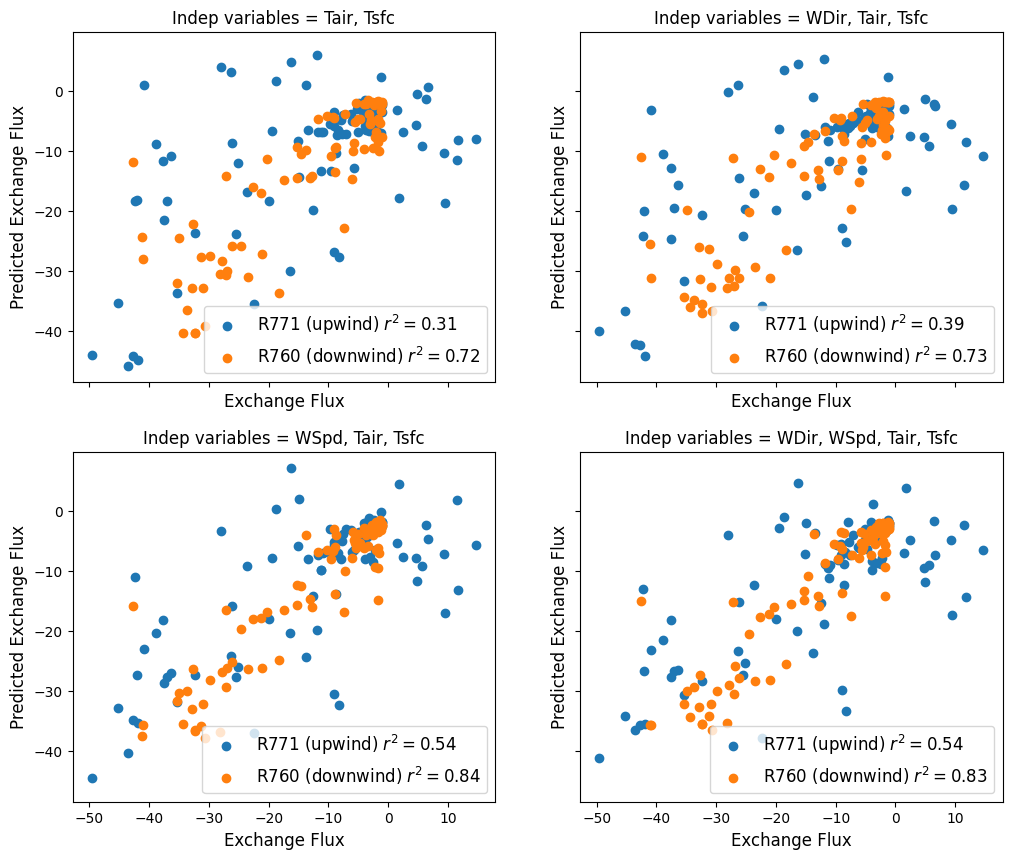

In [ ]:


y_var = 'Fx'

fig, axes = plt.subplots(2, 2, figsize= (12,10), sharex = True, sharey = True)
axes = axes.ravel()

x_vars = [ 'Tair', 'Tsfc']
ax = axes[0]
for site, df in zip(sites, dataframes):

    results = predict_fx(df, y_var, x_vars)

    ax.scatter(results['y_test'],results['y_pred'], 
               label = long_names[site] + f" $r^2={results['r2']:.2f}$")
    ax.legend(fontsize = 12)
    
ax.set_xlabel(f"{variables[y_var]}", fontsize = 12)
ax.set_ylabel(f"Predicted {variables[y_var]}",fontsize = 12)
ax.set_title('Indep variables = ' + ', '.join(x_vars), fontsize = 12)


x_vars = ['WSpd',  'Tair', 'Tsfc']

ax = axes[2]
for site, df in zip(sites, dataframes):
    #print ("site", long_names[site])
    results = predict_fx(df, y_var, x_vars)
    #print(f"Mean Squared Error: {results['mse']:.2f}")
    #print(f"R² Score: {results['r2']:.2f}")

    ax.scatter(results['y_test'],results['y_pred'],  label = long_names[site] + f" $r^2={results['r2']:.2f}$")
    ax.legend(fontsize = 12)
    
ax.set_xlabel(f"{variables[y_var]}",fontsize = 12)
ax.set_ylabel(f"Predicted {variables[y_var]}", fontsize = 12)
ax.set_title('Indep variables = ' + ', '.join(x_vars), fontsize = 12)


x_vars = ['WDir', 'Tair', 'Tsfc']
ax = axes[1]
for site, df in zip(sites, dataframes):

    results = predict_fx(df, y_var, x_vars)

    ax.scatter(results['y_test'],results['y_pred'], 
               label = long_names[site] + f" $r^2={results['r2']:.2f}$")
    ax.legend(fontsize = 12)
    
ax.set_xlabel(f"{variables[y_var]}", fontsize = 12)
ax.set_ylabel(f"Predicted {variables[y_var]}",fontsize = 12)
ax.set_title('Indep variables = ' + ', '.join(x_vars), fontsize = 12)




x_vars = ['WDir','WSpd', 'Tair', 'Tsfc']
ax = axes[3]
for site, df in zip(sites, dataframes):

    results = predict_fx(df, y_var, x_vars)

    ax.scatter(results['y_test'],results['y_pred'], 
               label = long_names[site] + f" $r^2={results['r2']:.2f}$")
    ax.legend(fontsize = 12)
    
ax.set_xlabel(f"{variables[y_var]}", fontsize = 12)
ax.set_ylabel(f"Predicted {variables[y_var]}",fontsize = 12)
ax.set_title('Indep variables = ' + ', '.join(x_vars), fontsize = 12)




<Axes: >

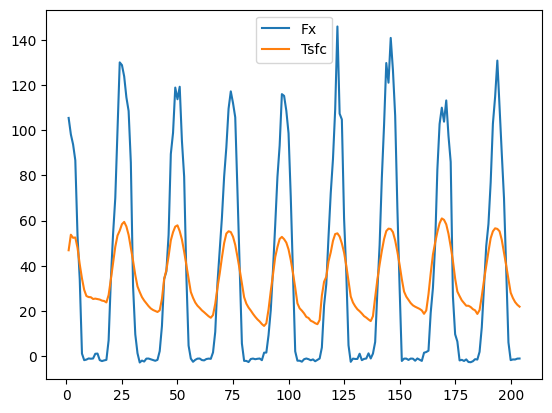

In [ ]:
fallow_df[['Fx','Tsfc']].plot()